In [18]:
from PySDM_examples.Shipway_and_Hill_2012 import plot, Simulation, Settings
from PySDM_examples.deJong_Azimi import Settings1D
from PySDM.dynamics.collisions.collision_kernels import Golovin, Long1974
from PySDM import Formulae
from PySDM.initialisation import spectra
from open_atmos_jupyter_utils import show_plot
from PySDM.physics import si, in_unit
from PySDM.exporters import NetCDFExporter_1d
from matplotlib import pyplot as plt
import xarray as xr

# Figure 7-8: Collision-Sedimentation Only

## 1. Run PySDM Case

In [60]:
params = {
    "n_sd_per_gridbox": 128,
    "dt": 10 * si.s,
    "dz": 50 * si.m,
    "particles_per_volume_STP": 100 / si.cm**3,
    "t_max": 3600 * si.s,
    "z_part": (0, 1.0),
    "rho_times_w_1": 0 * si.kg/si.m**3 * si.m/si.s,
}
settings = Settings1D(**params)

# Change the kernel
settings.collision_kernel = Long1974()
QT = 1e-3 * si.kg / si.kg
k = 2

# Compute the correct initial spectrum
mt = QT * settings.formulae.constants.rho_STP
theta_v = mt / k / params["particles_per_volume_STP"] / settings.formulae.constants.rho_w
settings.wet_radius_spectrum_per_mass_of_dry_air = spectra.Gamma(
    norm_factor = params["particles_per_volume_STP"] / settings.formulae.constants.rho_STP,
    k = k,
    theta = theta_v,
)

simulation = Simulation(settings)
output = simulation.run().products

# save data
filename = "../results/pysdm/pysdm_colSed_fullDomain_N0=100.nc"
nc_exporter = NetCDFExporter_1d(output, settings, simulation, filename)
nc_exporter.run()

## 2. Open Datasets and plot results

In [61]:
ds_pysdm = xr.open_dataset("../results/pysdm/pysdm_colSed_fullDomain_N0=100.nc")
ds_kid = xr.open_dataset("./Output_KiD_col_sed/CloudyPrecip_6/Flexible_6M,_Long.nc", group="profiles")

/var/folders/p0/4_dx18lx2hg2t2d47ltv2r8m00223t/T/ipykernel_23787/3253379184.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_pysdm = xr.open_dataset("../results/pysdm/pysdm_colSed_fullDomain_N0=100.nc")


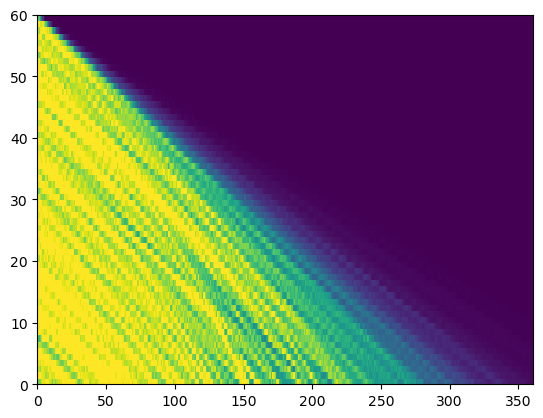

In [62]:
plt.pcolor(ds_pysdm["cloud water mixing ratio"]*1e-3 + ds_pysdm["rain water mixing ratio"]*1e-3, vmin=0, vmax=1e-3)

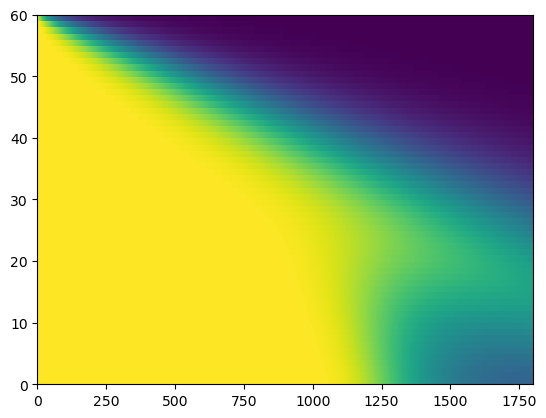

In [63]:
plt.pcolor(ds_kid["q_liq"].T + ds_kid["q_rai"].T, vmin=0, vmax=1e-3)

# Fig 9: Full KiD simulation

In [37]:
params = {
    "n_sd_per_gridbox": 128,
    "dt": 5 * si.s,
    "dz": 25 * si.m,
    "p0": 990 * si.hPa,
    "kappa": 0.9,
    "particles_per_volume_STP": 100 / si.cm**3,
    "t_max": 3600 * si.s,
    "z_max": 2000 * si.m,
    "rho_times_w_1": 2 * si.kg/si.m**3 * si.m/si.s,
    "collision_kernel": Golovin(b=1.5e3 / si.s),
    "formulae": Formulae(terminal_velocity="PowerSeries")
}
settings = Settings(**params)
simulation = Simulation(settings)
output = simulation.run().products

# save data
filename = "../results/pysdm/pysdm_fullKiD_w=2.nc"
nc_exporter = NetCDFExporter_1d(output, settings, simulation, filename)
nc_exporter.run()

In [38]:
ds_pysdm = xr.open_dataset("../results/pysdm/pysdm_fullKiD_w=2.nc")
cloudy6 = xr.open_dataset("./Output_CloudyMoisture_CloudyPrecip_6/Output.nc", group="profiles")
cloudy4 = xr.open_dataset("./Output_CloudyMoisture_CloudyPrecip_4/Output.nc", group="profiles")
cloudy11 = xr.open_dataset("./Output_CloudyMoisture_CloudyPrecip_11/Output.nc", group="profiles")
clima1m = xr.open_dataset("./Output_EquilibriumMoisture_Precipitation1M_CliMA_1M/Output.nc", group="profiles")
sb2m = xr.open_dataset("./Output_EquilibriumMoisture_Precipitation2M_SB2006/Output.nc", group="profiles")

/var/folders/p0/4_dx18lx2hg2t2d47ltv2r8m00223t/T/ipykernel_37816/494237226.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_pysdm = xr.open_dataset("../results/pysdm/pysdm_fullKiD_w=2.nc")


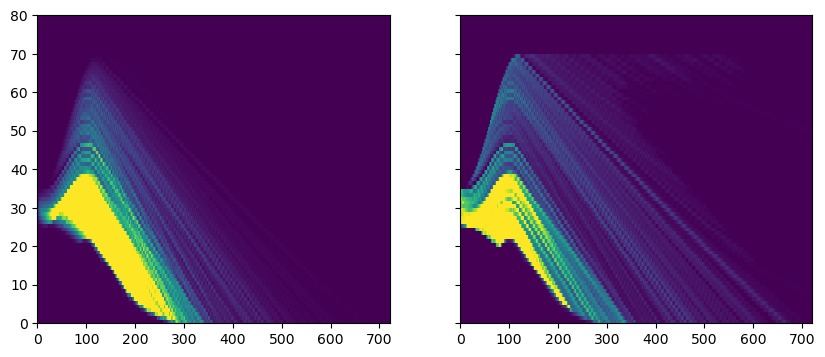

In [53]:
(fig, ax) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax[0].pcolor(ds_pysdm["cloud water mixing ratio"]*1e-3 + ds_pysdm["rain water mixing ratio"]*1e-3, vmin=0, vmax=1e-3)
ax[1].pcolor(ds_pysdm["nc"] + ds_pysdm["nr"], vmin=0, vmax=1e8)

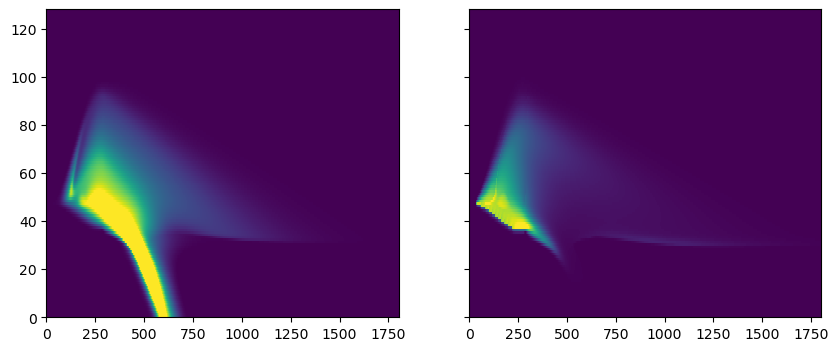

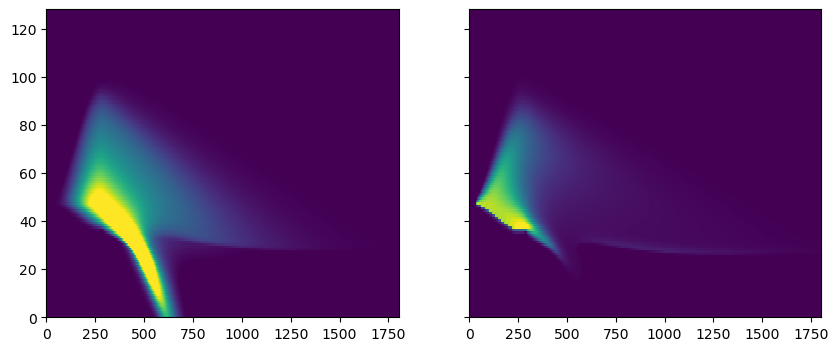

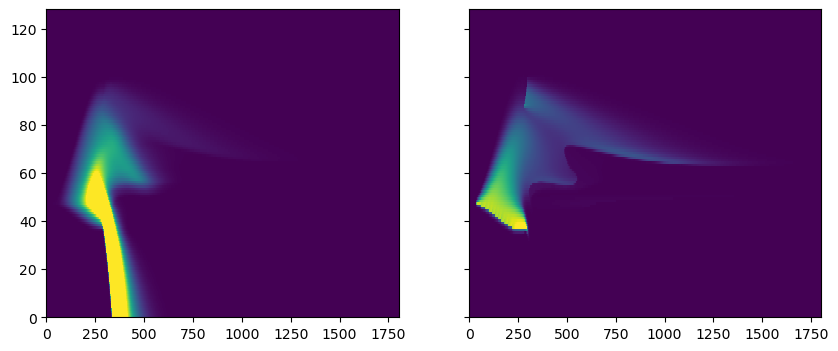

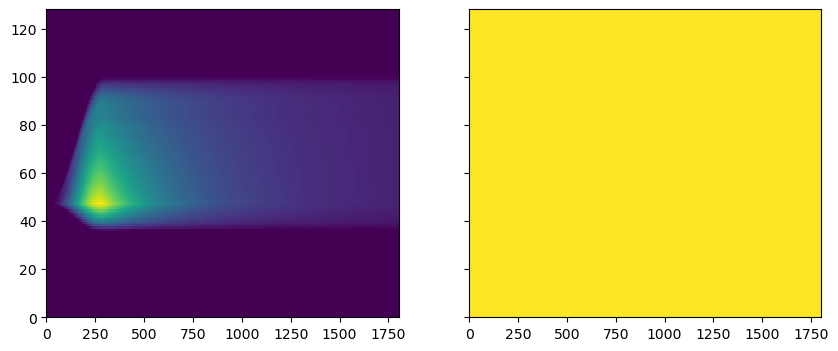

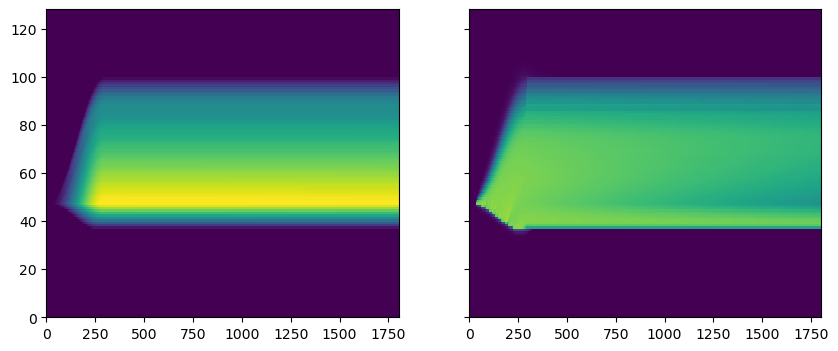

In [56]:
for ds in [cloudy6, cloudy4, cloudy11, clima1m, sb2m]:
    (fig, ax) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    ax[0].pcolor(ds["q_liq"].T + ds["q_rai"].T, vmin=0, vmax=1e-3)
    ax[1].pcolor(ds["N_liq"].T + ds["N_rai"].T, vmin=0, vmax=1e8)
    plt.show()